In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df=pd.read_csv(r"C:\Users\LENOVO\Downloads\finaletadataset.csv")

In [10]:
df.shape

(1644, 14)

In [11]:
df.head(10)

,run_id,train_no,station_code,timestamp,speed_kmh,distance_to_station_km,distance_to_destination_km,current_delay_minutes,historical_average_delay_minutes,scheduled_arrival_minutes,time_of_day,day_of_week,delay_type,actual_delay_at_station_minutes
0,509,3686,DER,2026-10-12T15:00:00.000Z,50.0,0.051885,943.136802,0.00,0.00,0.0,15,6,WEATHER,18.32
1,509,3686,BRKY,2026-10-12T15:06:04.000Z,45.0,2.764839,941.642472,18.32,18.32,6.1,15,6,SPEED,22.02
2,509,3686,CHL,2026-10-12T15:12:43.000Z,45.0,3.988862,915.723675,22.02,20.17,12.7,15,6,SPEED,28.31
3,509,3686,KRJ,2026-10-12T15:16:35.000Z,80.0,0.845991,897.905265,28.31,22.88,16.6,15,6,NONE,26.39
4,509,3686,KAMP,2026-10-12T15:20:26.000Z,80.0,0.177531,893.893665,26.39,23.76,20.4,15,6,NONE,23.50
5,509,3686,SNS,2026-10-12T15:30:23.000Z,50.0,7.124712,839.694757,23.50,23.71,30.4,15,6,WEATHER,34.78
6,509,3686,TDL,2026-10-12T15:33:07.000Z,50.0,0.578757,776.778293,34.78,25.55,33.1,15,6,WEATHER,49.00
7,509,3686,SKB,2026-10-12T15:45:46.000Z,50.0,9.622839,749.373865,49.00,28.90,45.8,15,6,WEATHER,54.69
8,509,3686,GHSR,2026-10-12T15:50:25.000Z,80.0,0.108070,649.996320,54.69,32.13,50.4,15,6,NONE,45.94
9,509,3686,PATA,2026-10-12T16:03:10.000Z,45.0,7.893463,644.442858,45.94,33.66,63.2,16,6,SPEED,42.55


In [12]:
from sklearn.preprocessing import LabelEncoder

le_station = LabelEncoder()
le_delay_type = LabelEncoder()

df["Station_Enc"] = le_station.fit_transform(df["station_code"])
df["Delay_Type_Enc"] = le_delay_type.fit_transform(df["delay_type"])

In [13]:
FEATURES = [
    "speed_kmh", "distance_to_station_km", "distance_to_destination_km",
    "current_delay_minutes", "historical_average_delay_minutes",
    "scheduled_arrival_minutes", "time_of_day", "day_of_week",
    "Station_Enc", "Delay_Type_Enc",
]
TARGET = "actual_delay_at_station_minutes"
X = df[FEATURES]
y = df[TARGET]
groups = df["run_id"]

In [15]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train rows: {len(X_train)} ({groups.iloc[train_idx].nunique()} trains)")
print(f"Test rows: {len(X_test)} ({groups.iloc[test_idx].nunique()} trains)")

Train rows: 1314 (72 trains)
Test rows: 330 (19 trains)


In [16]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=8, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42
    ),
}

results = []
best_model, best_name, best_mae = None, None, float("inf")

for name, m in models.items():
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "MAE": round(mae, 2), "RMSE": round(rmse, 2), "R2": round(r2, 3)})
    if mae < best_mae:
        best_mae, best_model, best_name = mae, m, name

results_df = pd.DataFrame(results)
print(results_df)
print(f"\nBest model: {best_name} (MAE = {best_mae:.2f} min)")

               Model   MAE  RMSE     R2
0      Random Forest  3.16  3.99  0.966
1  Gradient Boosting  3.11  3.92  0.967

Best model: Gradient Boosting (MAE = 3.11 min)


In [17]:
preds = best_model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"Best Model: {best_name}")
print(f"MAE: {mae:.2f} min")
print(f"RMSE: {rmse:.2f} min")
print(f"R2: {r2:.3f}")

Best Model: Gradient Boosting
MAE: 3.11 min
RMSE: 3.92 min
R2: 0.967


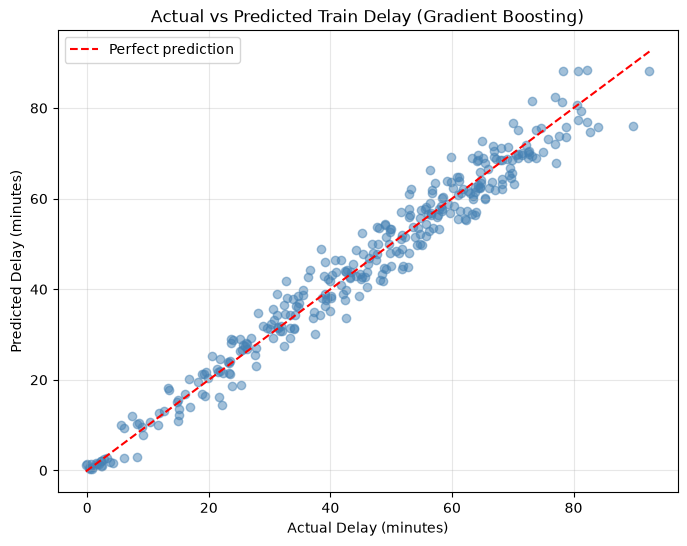

In [18]:
#actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.5, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect prediction")
plt.xlabel("Actual Delay (minutes)")
plt.ylabel("Predicted Delay (minutes)")
plt.title(f"Actual vs Predicted Train Delay ({best_name})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

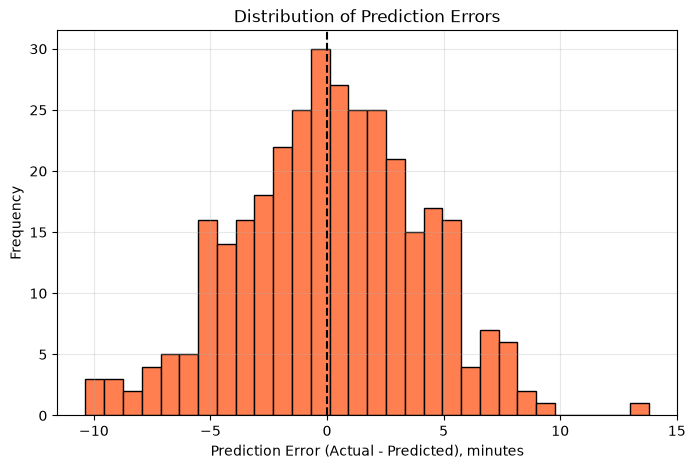

In [19]:
# Residuals (errors) distribution
residuals = y_test - preds

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, color="coral", edgecolor="black")
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Prediction Error (Actual - Predicted), minutes")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.grid(True, alpha=0.3)
plt.show()

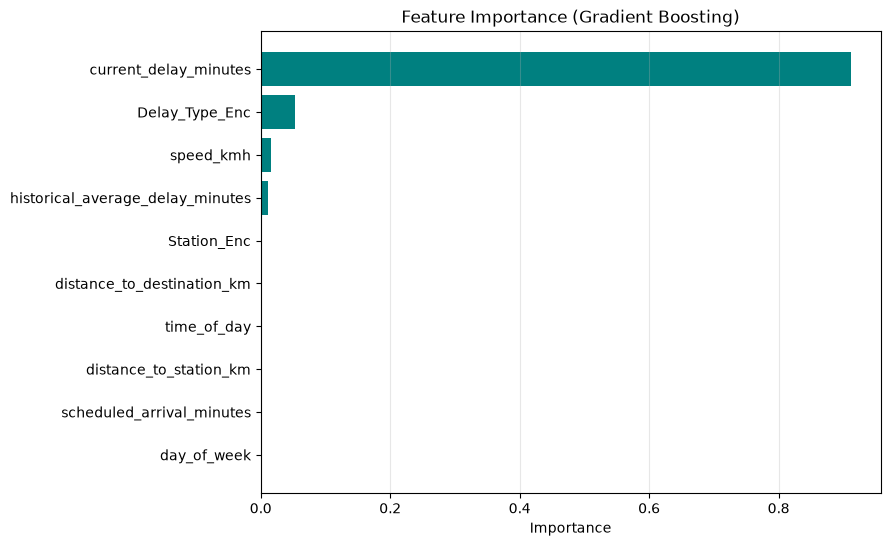

In [20]:
# Feature importance
importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(importances.index, importances.values, color="teal")
plt.xlabel("Importance")
plt.title(f"Feature Importance ({best_name})")
plt.grid(True, alpha=0.3, axis="x")
plt.show()

In [21]:
import joblib

joblib.dump({
    "model": best_model,
    "model_name": best_name,
    "features": FEATURES,
    "le_station": le_station,
    "le_delay_type": le_delay_type,
}, "eta_delay_model.pkl")

print(f"Saved best model: {best_name}")

Saved best model: Gradient Boosting


In [22]:
import os
print(os.path.exists("eta_delay_model.pkl"))
print(os.path.abspath("eta_delay_model.pkl"))  

True
C:\Users\LENOVO\eta_delay_model.pkl
